# 04 · Selección del umbral τ
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `5_seleccion_umbral_ciencia.ipynb`

---

### ¿Qué hace este notebook?

Determina el umbral óptimo τ para decidir si un tweet contiene  
una mención efectiva de salud. El proceso tiene **dos fases**:

**FASE A — Preparación** *(correr primero)*
1. Filtra tweets con score ≥ 0.43
2. Muestra 10 tweets por subcategoría de forma balanceada
3. Exporta `seleccion_umbral.xlsx` para anotación manual
4. **→ Pausa: anotar la columna `valido_salud` (1 = sí es salud, 0 = no)**

**FASE B — Optimización** *(correr después de anotar)*
5. Lee el archivo anotado
6. Calcula accuracy para cada umbral posible (igual que Karen: argmax)
7. Selecciona τ óptimo y lo aplica al corpus completo
8. Guarda el corpus final etiquetado

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad | Chunk (`chunk_uid`) | Tweet (`chunk_uid = id_doc + '_' + chunk_id`) |
| Columna a anotar | `valido_ciencia` | `valido_salud` |
| Subcategorías | Ciencia (17) | Salud (12) |
| Muestra por subcategoría | 10 | 10 |
| Método τ óptimo | argmax(accuracy) | argmax(accuracy) ✅ |

**Entradas:**
- `resultadosPropios/similitudes_chunks.parquet`

**Salidas:**
- `resultadosPropios/seleccion_umbral.xlsx` ← **anotar manualmente**
- `resultadosPropios/fig_scores_por_etiqueta.png`
- `resultadosPropios/fig_accuracy_umbral.png`
- `resultadosPropios/tweets_etiquetados_final.parquet`
- `resultadosPropios/salud_tweets_final.parquet`

## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

SCORE_MINIMO = 0.43   # filtro previo al muestreo (igual que el paper)
MUESTRA_N    = 10     # tweets por subcategoria para validacion manual

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Score minimo   : {SCORE_MINIMO}')
print(f'  Muestra / cat  : {MUESTRA_N}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento
  Score minimo   : 0.43
  Muestra / cat  : 10


---
## ─── FASE A: Preparación de la muestra para anotación manual ───

## 1 · Cargar similitudes

In [2]:
# ============================================================
# CELL 1 — CARGA
# Equivalente a: sim_df = pd.read_excel('similitudes_chunks.xlsx')
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sim_df = pd.read_parquet(DATA_PROCESSED / 'similitudes_chunks.parquet')

# Columnas de subcategorias (igual que Karen: sim_df.columns[3:20])
subcat_cols = sim_df.columns[3:].tolist()  # despues de chunk_id, id_doc, texto_chunk

# Asegurar que las columnas de subcategorias son numericas
for col in subcat_cols:
    sim_df[col] = pd.to_numeric(sim_df[col], errors='coerce')

print(f'Chunks cargados        : {len(sim_df):,}')
print(f'Columnas de subcats    : {subcat_cols}')
sim_df.head(3)


Chunks cargados        : 151,424
Columnas de subcats    : ['Comp_Desinfectante', 'Comp_Distanciamiento', 'Comp_Etiqueta_tos_codo', 'Comp_Etiqueta_tos_panuelo', 'Comp_Evitar_reuniones', 'Comp_Lavado_manos', 'Comp_Mascarilla']


,chunk_id,id_doc,texto_chunk,Comp_Desinfectante,Comp_Distanciamiento,Comp_Etiqueta_tos_codo,Comp_Etiqueta_tos_panuelo,Comp_Evitar_reuniones,Comp_Lavado_manos,Comp_Mascarilla
0,1_1,1,VDEO Reos que no están contagiados con COVID19...,0.047033,0.090497,0.200843,0.190857,0.206044,0.100137,0.196007
1,2_1,2,ya se enteraron de la muerte supestamente por ...,0.022196,0.069358,0.274243,0.250329,0.180717,0.166653,0.193347
2,3_1,3,El calvario de una familia en Cali por su mamá...,0.008944,0.179625,0.258756,0.244330,0.271494,0.085441,0.162381


## 2 · Filtrar scores ≥ 0.43 y muestrear por subcategoría
Replica exacta de las celdas 4–8 del paper.

In [3]:
# ============================================================
# CELL 2 — FILTRAR Y MUESTREAR
# Equivalente a celdas 4-8 del paper
# ============================================================

# Crear chunk_uid igual que Karen: id_doc_str + '_' + chunk_id_str
sim_df['chunk_uid'] = sim_df['id_doc'].astype(str) + '_' + sim_df['chunk_id'].astype(str)

sim_temp = sim_df[subcat_cols].copy()
for col in subcat_cols:
    sim_temp[col] = pd.to_numeric(sim_temp[col], errors='coerce')

# Lista donde acumulamos resultados (estructura identica a Karen)
sim_filtered = []

for idx, row in sim_temp.iterrows():
    best_cat   = max(subcat_cols, key=lambda c: row[c])
    best_score = row[best_cat]

    if best_score >= SCORE_MINIMO:
        sim_filtered.append({
            'chunk_id'  : sim_df.at[idx, 'chunk_id'],
            'chunk_uid' : sim_df.at[idx, 'chunk_uid'],
            'texto_chunk': sim_df.at[idx, 'texto_chunk'],
            'categoria' : best_cat,
            'score'     : best_score,
        })

sim_filtered = pd.DataFrame(sim_filtered)
print(f'Total de chunks elegibles: {len(sim_filtered):,}')


Total de chunks elegibles: 9,284


## 3 · Selección balanceada por subcategoría

In [4]:
# ============================================================
# CELL 3 — SELECCION BALANCEADA
# Equivalente a celdas 6-8 del paper
# ============================================================

selected_chunks = []

for cat in subcat_cols:
    candidatos = sim_filtered[sim_filtered['categoria'] == cat]

    if len(candidatos) > MUESTRA_N:
        muestra = candidatos.sample(MUESTRA_N, random_state=42)
    else:
        muestra = candidatos   # si no hay suficientes, tomamos todos

    selected_chunks.append(muestra)

# Concatenar y eliminar duplicados por chunk_uid (igual que Karen)
final_selection = pd.concat(selected_chunks, ignore_index=True)
final_selection = final_selection.drop_duplicates(subset=['chunk_uid'])

# Columna vacia para anotar manualmente (Karen: 'valido_ciencia')
final_selection['valido_comportamiento'] = ''

print(f'Muestra total para anotacion: {len(final_selection)} chunks')
final_selection.head()


Muestra total para anotacion: 70 chunks


,chunk_id,chunk_uid,texto_chunk,categoria,score,valido_comportamiento
0,132604_1,132604_132604_1,"Es un spray con etiqueta de laca, pero tiene u...",Comp_Desinfectante,0.463062,
1,425_1,425_425_1,Coviandina en cumplimiento al Plan de Responsa...,Comp_Desinfectante,0.438854,
2,53599_1,53599_53599_1,Continuamos con la entrega de gel antibacteria...,Comp_Desinfectante,0.458217,
3,45208_1,45208_45208_1,"PUERTO PARRA, Santander, hace contrato para pr...",Comp_Desinfectante,0.561991,
4,19024_1,19024_19024_1,Carceletas fueron desinfectadas con fórmula us...,Comp_Desinfectante,0.460742,


## 4 · Exportar para anotación manual

In [5]:
# ============================================================
# CELL 4 — EXPORTAR
# Equivalente a: final_selection.to_excel('seleccion_umbral.xlsx')
# ============================================================

ruta_salida = DATA_PROCESSED / 'seleccion_umbral.xlsx'
final_selection.to_excel(ruta_salida, index=False, engine='openpyxl')

print(f'[GUARDADO] {ruta_salida}')
print()
print('*** ACCION REQUERIDA ***')
print('1. Abre el archivo seleccion_umbral.xlsx')
print('2. Lee cada tweet en la columna texto_chunk')
print('3. Rellena la columna valido_comportamiento:')
print('      1 = el tweet habla de salud (segun la categoria asignada)')
print('      0 = el tweet NO habla de salud')
print('4. Guarda el archivo como seleccion_umbral_anotado.xlsx')
print('5. Vuelve a correr desde la FASE B')


[GUARDADO] C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\seleccion_umbral.xlsx

*** ACCION REQUERIDA ***
1. Abre el archivo seleccion_umbral.xlsx
2. Lee cada tweet en la columna texto_chunk
3. Rellena la columna valido_comportamiento:
      1 = el tweet habla de salud (segun la categoria asignada)
      0 = el tweet NO habla de salud
4. Guarda el archivo como seleccion_umbral_anotado.xlsx
5. Vuelve a correr desde la FASE B


---
## ─── FASE B: Optimización del umbral *(correr tras anotar)* ───

## 5 · Leer archivo anotado

In [6]:
# ============================================================
# CELL 5 — LEER ARCHIVO ANOTADO
# Equivalente a: df_etiquetado = pd.read_excel('seleccion_umbral_etiquetado.xlsx')
# ============================================================

ruta_anotado = DATA_PROCESSED / 'seleccion_umbral_anotado.xlsx'

df_etiquetado = pd.read_excel(ruta_anotado, engine='openpyxl')

# Asegurar que la columna es numerica (igual que Karen)
df_etiquetado['valido_comportamiento'] = pd.to_numeric(
    df_etiquetado['valido_comportamiento'], errors='coerce'
)

print(f'Valores unicos en valido_comportamiento: {df_etiquetado["valido_comportamiento"].unique()}')
df_etiquetado.head(3)


Valores unicos en valido_comportamiento: [0 1]


,chunk_id,chunk_uid,texto_chunk,categoria,score,valido_comportamiento
0,132604_1,132604_132604_1,"Es un spray con etiqueta de laca, pero tiene u...",Comp_Desinfectante,0.463062,0
1,425_1,425_425_1,Coviandina en cumplimiento al Plan de Responsa...,Comp_Desinfectante,0.438854,1
2,53599_1,53599_53599_1,Continuamos con la entrega de gel antibacteria...,Comp_Desinfectante,0.458217,1


## 6 · Distribución de scores por etiqueta
Equivalente a celdas 17–18 del paper (mismos colores).

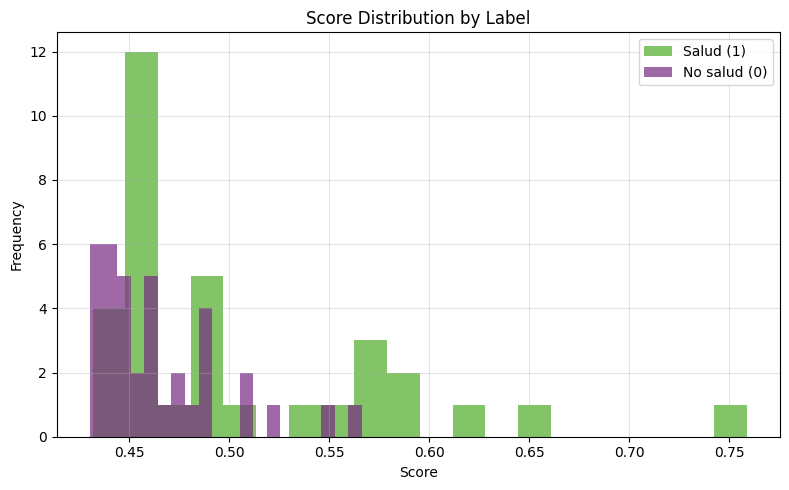

In [7]:
# ============================================================
# CELL 6 — DISTRIBUCION DE SCORES POR ETIQUETA
# Equivalente a celdas 17-18 del paper
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(
    df_etiquetado[df_etiquetado['valido_comportamiento'] == 1]['score'],
    bins=20, alpha=0.7, label='Salud (1)', color='#4dac26'
)
plt.hist(
    df_etiquetado[df_etiquetado['valido_comportamiento'] == 0]['score'],
    bins=20, alpha=0.7, label='No salud (0)', color='#762a83'
)
plt.grid(True, alpha=0.35)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Score Distribution by Label')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_scores_por_etiqueta.png', dpi=300)
plt.show()


## 7 · Encontrar el umbral óptimo τ
Replica exacta de Karen: barre todos los umbrales con `np.linspace(0, 1, 1001)`  
y elige el que **maximiza la accuracy** contra las etiquetas manuales.

In [8]:
# ============================================================
# CELL 7 — UMBRAL OPTIMO: argmax(accuracy)
# Replica exacta de Karen (celdas 20-21)
# ============================================================

umbrales    = np.linspace(0, 1, 1001)
mejor_umbral = None
mejor_acc    = 0
resultados   = []

for u in umbrales:
    pred = (df_etiquetado['score'] >= u).astype(int)
    acc  = (pred == df_etiquetado['valido_comportamiento']).mean()
    resultados.append((u, acc))
    if acc > mejor_acc:
        mejor_acc    = acc
        mejor_umbral = u

print(f'Mejor umbral: {mejor_umbral:.3f}  accuracy = {mejor_acc:.3f}')


Mejor umbral: 0.488  accuracy = 0.657


## 8 · Gráfica: accuracy como función del umbral
Réplica exacta de celdas 23–24 del paper (mismos colores y estilo).

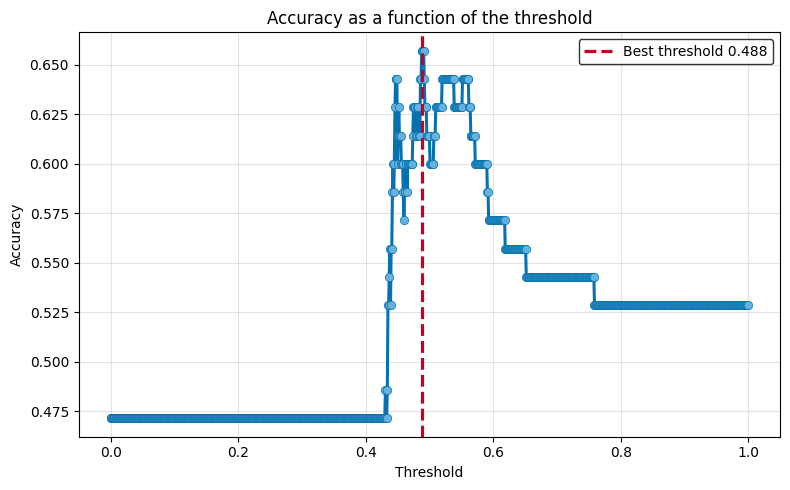

In [9]:
# ============================================================
# CELL 8 — GRAFICA ACCURACY vs UMBRAL
# Replica exacta de celdas 23-24 del paper
# ============================================================

color_line      = '#0571b0'
color_threshold = '#ca0020'
color_fill      = '#66b2dd'

thresholds = [r[0] for r in resultados]
accuracies = [r[1] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(
    thresholds, accuracies,
    marker='o', linewidth=2.2, markersize=6,
    color=color_line,
    markerfacecolor=color_fill,
    markeredgecolor=color_line,
    markeredgewidth=0.5,
)
plt.axvline(
    mejor_umbral,
    color=color_threshold, linestyle='--', linewidth=2.3,
    label=f'Best threshold {mejor_umbral:.3f}'
)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy as a function of the threshold')
plt.grid(True, alpha=0.35)
plt.legend(frameon=True, facecolor='white', edgecolor='black')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_accuracy_umbral.png', dpi=300)
plt.show()


## 9 · Aplicar umbral óptimo al corpus completo
Con τ calibrado, re-etiquetamos todos los tweets y guardamos el corpus definitivo.

In [10]:
# ============================================================
# CELL 9 — APLICAR UMBRAL AL CORPUS COMPLETO
# ============================================================

TAU = mejor_umbral

sim_full = pd.read_parquet(DATA_PROCESSED / 'similitudes_chunks.parquet')
subcat_cols_full = sim_full.columns[3:].tolist()

for col in subcat_cols_full:
    sim_full[col] = pd.to_numeric(sim_full[col], errors='coerce')

sim_temp_full            = sim_full[subcat_cols_full].astype(float)
sim_full['score_max']    = sim_temp_full.max(axis=1)
sim_full['subcat_max']   = sim_temp_full.idxmax(axis=1)
sim_full['etiqueta_comportamiento'] = (sim_full['score_max'] >= TAU).astype(int)
sim_full['categoria_detectada'] = sim_full.apply(
    lambda r: r['subcat_max'] if r['etiqueta_comportamiento'] == 1 else 'ninguna',
    axis=1
)

n_salud = sim_full['etiqueta_comportamiento'].sum()
print(f'Umbral optimo tau = {TAU:.3f}')
print(f'Tweets con salud  : {n_salud:,} ({n_salud/len(sim_full)*100:.1f}%)')
print()
print('Distribucion por subcategoria:')
print(
    sim_full[sim_full['etiqueta_comportamiento'] == 1]['categoria_detectada']
    .value_counts().to_string()
)


Umbral optimo tau = 0.488
Tweets con salud  : 2,804 (1.9%)

Distribucion por subcategoria:
categoria_detectada
Comp_Evitar_reuniones        1193
Comp_Etiqueta_tos_codo        775
Comp_Etiqueta_tos_panuelo     313
Comp_Lavado_manos             264
Comp_Mascarilla               144
Comp_Distanciamiento           76
Comp_Desinfectante             39


## 10 · Guardar corpus etiquetado definitivo

In [11]:
# ============================================================
# CELL 10 — GUARDAR
# Equivalente a:
#   resultado.to_excel('chunks_etiquetados_binario.xlsx')
#   resultado_ciencia.to_excel('ciencia_chunks.xlsx')
# ============================================================

# Corpus completo etiquetado
sim_full.to_parquet(DATA_PROCESSED / 'comportamiento_etiquetados_final.parquet', index=False)
print(f'[GUARDADO] comportamiento_etiquetados_final.parquet  ({len(sim_full):,} filas)')

# Solo tweets de salud
salud_final = sim_full[sim_full['etiqueta_comportamiento'] == 1].copy()
salud_final.to_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet', index=False)
salud_final.to_excel(DATA_PROCESSED / 'comportamiento_tweets_final.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] comportamiento_tweets_final  ({len(salud_final):,} filas)')

print()
print(f'  Total tweets         : {len(sim_full):,}')
print(f'  Tweets con salud     : {len(salud_final):,} ({len(salud_final)/len(sim_full)*100:.1f}%)')
print(f'  Umbral tau optimo    : {TAU:.3f}')
print(f'  Accuracy validacion  : {mejor_acc:.3f}')
print()
print('Notebook 04 completado.')
print('Siguiente -> 05_descriptivos_salud.ipynb')


[GUARDADO] comportamiento_etiquetados_final.parquet  (151,424 filas)
[GUARDADO] comportamiento_tweets_final  (2,804 filas)

  Total tweets         : 151,424
  Tweets con salud     : 2,804 (1.9%)
  Umbral tau optimo    : 0.488
  Accuracy validacion  : 0.657

Notebook 04 completado.
Siguiente -> 05_descriptivos_salud.ipynb
